# Quantum Optics - Homework 5 - Quantum limits to displacement sensing

## Jan Chelmecki

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In a quantum optical measurement, all beams will be subject to a noise smaller than some nonzero minimal value. For coherent states, the noise is independent of the amplitude, and so it is of interest to increase the latter to attain a better signal to noise ratio. However, by doing so, we also increase our impact on the system (radiation pressure, for example) and for very strong signals, the dynamics of the system will be dominated by this undesirable effect of the apparatus, making the inherent dynamics much smaller by ampitude and hence, again, difficult to measure. The compromise above leads to the concept of the Standard Quantum Limit, which might be defied for example by using squeezed light or, as in the paper, by real-time control of the system basing on measurement outcomes.

Here, however, we will only analyze the backaction 

Let's unpack the data and plot it.

In [3]:
data = pd.read_csv("HW5_data.csv")
data

,freq_0_data,Syy_0_data,freq_1_data,Syy_1_data,freq_2_data,Syy_2_data,freq_3_data,Syy_3_data,freq_4_data,Syy_4_data,...,freq_1_fit,Syy_1_fit,freq_2_fit,Syy_2_fit,freq_3_fit,Syy_3_fit,freq_4_fit,Syy_4_fit,freq_5_fit,Syy_5_fit
0,-9.995726,2.190000e-34,-9.990888,3.610000e-34,-9.986191,5.530000e-34,-9.994054,1.540000e-33,-9.986738,6.060000e-33,...,-9.997771,3.290000e-34,-9.997713,6.280000e-34,-9.997656,1.510000e-33,-9.997780,5.750000e-33,-9.99771,1.580000e-32
1,-9.935726,2.050000e-34,-9.930888,3.150000e-34,-9.956191,6.130000e-34,-9.964054,1.630000e-33,-9.956738,6.460000e-33,...,-9.992971,3.290000e-34,-9.992913,6.280000e-34,-9.992856,1.510000e-33,-9.992980,5.750000e-33,-9.99291,1.580000e-32
2,-9.875726,2.130000e-34,-9.870888,2.860000e-34,-9.926191,5.950000e-34,-9.934054,1.500000e-33,-9.926738,7.610000e-33,...,-9.988171,3.290000e-34,-9.988113,6.280000e-34,-9.988056,1.510000e-33,-9.988180,5.750000e-33,-9.98811,1.580000e-32
3,-9.815726,2.230000e-34,-9.810888,3.280000e-34,-9.896191,5.650000e-34,-9.904054,1.470000e-33,-9.896738,5.800000e-33,...,-9.983371,3.290000e-34,-9.983313,6.280000e-34,-9.983256,1.510000e-33,-9.983380,5.750000e-33,-9.98331,1.580000e-32
4,-9.755726,2.190000e-34,-9.750888,3.320000e-34,-9.866191,5.620000e-34,-9.874054,1.390000e-33,-9.866738,5.170000e-33,...,-9.978571,3.290000e-34,-9.978513,6.280000e-34,-9.978456,1.510000e-33,-9.978580,5.750000e-33,-9.97851,1.580000e-32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.975229,3.290000e-34,9.975287,6.280000e-34,9.975344,1.510000e-33,9.975219,5.750000e-33,9.97529,1.580000e-32
4162,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.980029,3.290000e-34,9.980087,6.280000e-34,9.980144,1.510000e-33,9.980019,5.750000e-33,9.98009,1.580000e-32
4163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.984829,3.290000e-34,9.984887,6.280000e-34,9.984944,1.510000e-33,9.984820,5.750000e-33,9.98489,1.580000e-32
4164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.989629,3.290000e-34,9.989687,6.280000e-34,9.989744,1.510000e-33,9.989620,5.750000e-33,9.98969,1.580000e-32


Text(0, 0.5, '$ S_{yy}(\\Omega) \\;\\; (m^2 Hz^{-1})$')

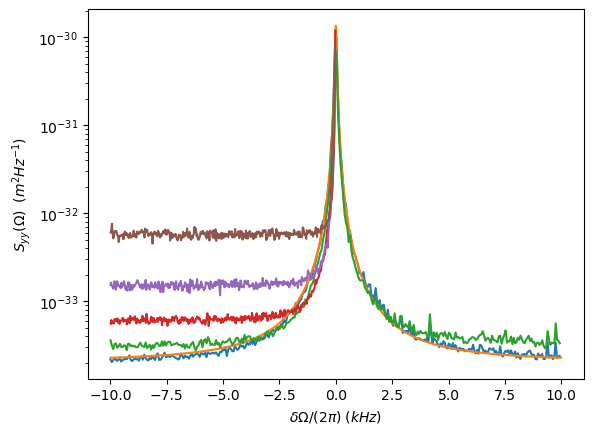

In [84]:
plt.semilogy(data["freq_0_data"], data["Syy_0_data"])
plt.semilogy(data["freq_0_fit"], data["Syy_0_fit"])
plt.semilogy(data["freq_1_data"], data["Syy_1_data"])
plt.semilogy(data["freq_2_data"], data["Syy_2_data"])
plt.semilogy(data["freq_3_data"], data["Syy_3_data"])
plt.semilogy(data["freq_4_data"], data["Syy_4_data"])
plt.xlabel("$\delta \Omega /(2\pi) \; (kHz) $")
plt.ylabel("$ S_{yy}(\Omega) \;\; (m^2 Hz^{-1})$")

Rather annoyingly, for some curves, half of the data is missing. We will remeady this but assuming the functions are symmetric around 0 and by reflecting the left branch for the curves that miss values. Also, due to the choice of the SI units, the values of $S_yy$ are of order of $10^{-30}$, which is potentially bad for numerics. I will alleviate this issue by rescaling $S_yy$ in my code.

In [58]:
data.columns

Index(['freq_0_data', 'Syy_0_data', 'freq_1_data', 'Syy_1_data', 'freq_2_data',
       'Syy_2_data', 'freq_3_data', 'Syy_3_data', 'freq_4_data', 'Syy_4_data',
       'freq_5_data', 'Syy_5_data', 'freq_0_fit', 'Syy_0_fit', 'freq_1_fit',
       'Syy_1_fit', 'freq_2_fit', 'Syy_2_fit', 'freq_3_fit', 'Syy_3_fit',
       'freq_4_fit', 'Syy_4_fit', 'freq_5_fit', 'Syy_5_fit'],
      dtype='object')

In [91]:
(data["freq_4_data"]).min()

-9.98673841561493

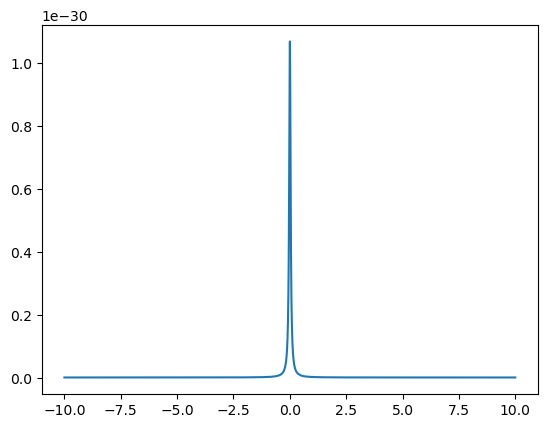

In [60]:
x = data["freq_1_fit"].dropna()
y = data["Syy_1_fit"].dropna()
plt.plot(x,y)

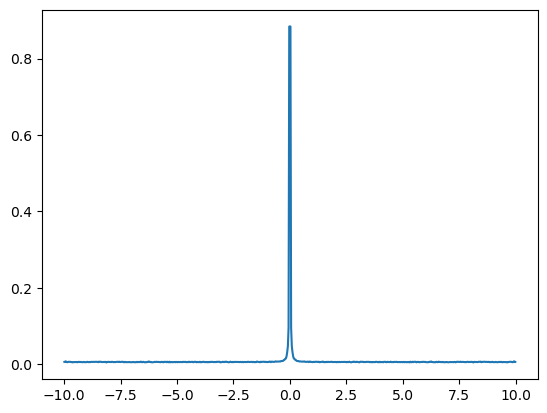

In [98]:
x = np.array(data["freq_4_data"].dropna())
y = np.array(data["Syy_4_data"].dropna()*1E30)
x = np.concatenate((x,-x[::-1]))
y = np.concatenate((y,y[::-1]))
plt.plot(x,y)

In [96]:
np.concatenate((x,-x))

array([-9.98673842, -9.95673842, -9.92673842, -9.89673842, -9.86673842,
       -9.83673842, -9.80673842, -9.77673842, -9.74673842, -9.71673842,
       -9.68673842, -9.65673842, -9.62673842, -9.59673842, -9.56673842,
       -9.53673842, -9.50673842, -9.47673842, -9.44673842, -9.41673842,
       -9.38673842, -9.35673842, -9.32673842, -9.29673842, -9.26673842,
       -9.23673842, -9.20673842, -9.17673842, -9.14673842, -9.11673842,
       -9.08673842, -9.05673842, -9.02673842, -8.99673842, -8.96673842,
       -8.93673842, -8.90673842, -8.87673842, -8.84673842, -8.81673842,
       -8.78673842, -8.75673842, -8.72673842, -8.69673842, -8.66673842,
       -8.63673842, -8.60673842, -8.57673842, -8.54673842, -8.51673842,
       -8.48673842, -8.45673842, -8.42673842, -8.39673842, -8.36673842,
       -8.33673842, -8.30673842, -8.27673842, -8.24673842, -8.21673842,
       -8.18673842, -8.15673842, -8.12673842, -8.09673842, -8.06673842,
       -8.03673842, -8.00673842, -7.97673842, -7.94673842, -7.91

Function coefficients:
[ 1.50760768e+00 -4.12294767e-02  3.30652974e-04]
Covariance of coefficients:
[[1.49710656e-04 4.72410843e-06 2.67119257e-07]
 [4.72410843e-06 1.68336639e-07 1.33627716e-08]
 [2.67119257e-07 1.33627716e-08 4.89466006e-08]]


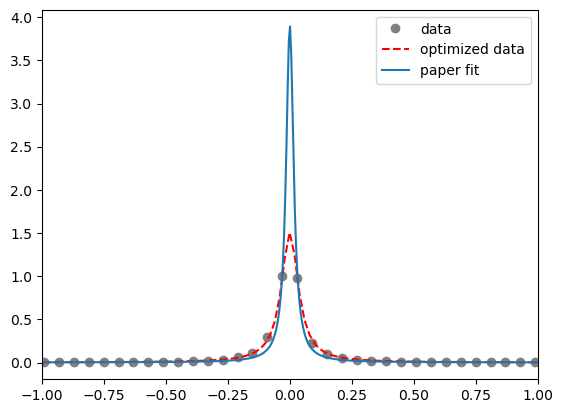

In [141]:
from scipy.optimize import curve_fit
x = np.array(data["freq_1_data"].dropna())
y = np.array(data["Syy_1_data"].dropna())
y_max = np.copy(np.max(y))
y = y/y_max

if np.max(x)<0:
    x = np.concatenate((x,-x[::-1]))
    y = np.concatenate((y,y[::-1]))

# Lorentz function model
def lorentz(x, a, b,c):
    return a /(1+ (x/b)**2) +c

# Fit the model to the data
param, param_cov = curve_fit(lorentz, x, y)

print("Function coefficients:")
print(param)
print("Covariance of coefficients:")
print(param_cov)

# Generate fitted values using the optimized parameters
x_vals = np.linspace(np.min(x), np.max(x), 1000)
ans = param[0]/(1+ (x_vals/param[1])**2)+param[2]

# Plot original and fitted data
plt.plot(x, y, 'o', color='grey', label="data")
plt.plot(x_vals, ans, '--', color='red', label="optimized data")
plt.plot(data["freq_2_fit"].dropna(), data["Syy_2_fit"].dropna()/y_max, label="paper fit")
plt.legend()
plt.xlim(-1,1)
plt.show()

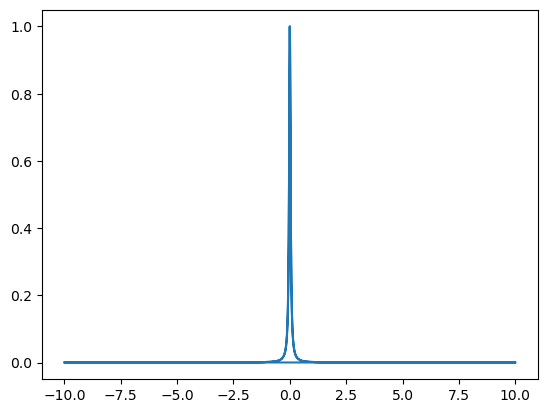

In [116]:
x = np.array(data["freq_1_fit"].dropna())
y = np.array(data["Syy_1_fit"].dropna())
max_S_yy = np.max(y)
y = y/max_S_yy
x = np.concatenate((x,-x[::-1]))
y = np.concatenate((y,y[::-1]))
# Lorentz function model
def lorentz(x, a, b,c):
    return a /(1+ (x/b)**2)+c

# Fit the model to the data
plt.plot(x,y)
param, param_cov = curve_fit(lorentz, x, y, maxfev=5000)

# Working

Function coefficients:
[1.03421895e+00 4.12294724e-02 2.26828106e-04]
Covariance of coefficients:
[[ 7.04516796e-05 -3.24069582e-06  1.25703404e-07]
 [-3.24069582e-06  1.68336278e-07 -9.16684507e-09]
 [ 1.25703404e-07 -9.16684507e-09  2.30340740e-08]]


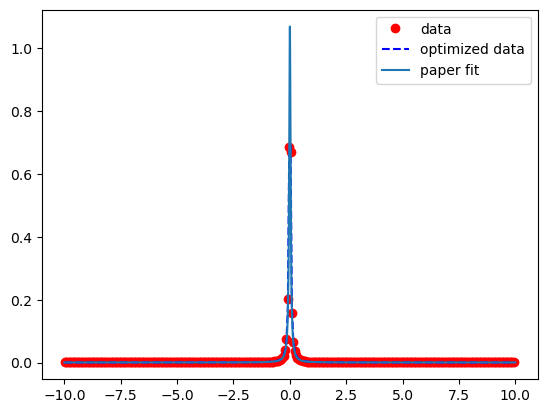

In [120]:
from scipy.optimize import curve_fit
x = data["freq_1_data"].dropna()
y = data["Syy_1_data"].dropna()*1E30

# Lorentz function model
def lorentz(x, a, b,c):
    return a /(1+ (x/b)**2)+c

# Fit the model to the data
param, param_cov = curve_fit(lorentz, x, y)

print("Function coefficients:")
print(param)
print("Covariance of coefficients:")
print(param_cov)

# Generate fitted values using the optimized parameters
ans = param[0]/(1+ (x/param[1])**2) + param[2]

# Plot original and fitted data
plt.plot(x, y, 'o', color='red', label="data")
plt.plot(x, ans, '--', color='blue', label="optimized data")
plt.plot(data["freq_1_fit"].dropna(), data["Syy_1_fit"].dropna()*1E30, label="paper fit")
plt.legend()
plt.show()

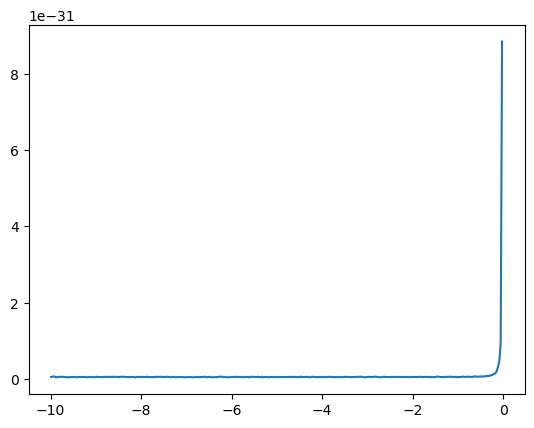

In [28]:
plt.plot(data["freq_4_data"], data["Syy_4_data"])

Sine function coefficients:
[4.0110143e-20 1.0000000e+00]
Covariance of coefficients:
[[9.72491374e-42 2.64967172e-32]
 [2.64967172e-32 1.44328838e-22]]


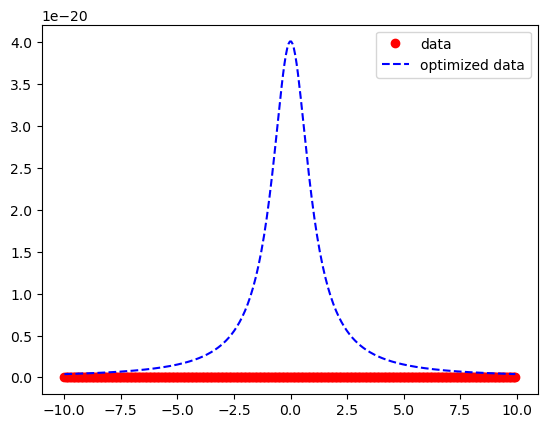

In [75]:
import numpy as np
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
x = data["freq_1_data"].dropna()
y = data["Syy_1_data"].dropna()

# Lorentz function model
def lorentz(x, a, b):
    return a/(1+ (x/b)**2)

# Fit the model to the data
param, param_cov = curve_fit(lorentz, x, y)

print("Sine function coefficients:")
print(param)
print("Covariance of coefficients:")
print(param_cov)

# Generate fitted values using the optimized parameters
ans = param[0]/(1+ (x/param[1])**2)

# Plot original and fitted data
plt.plot(x, y, 'o', color='red', label="data")
plt.plot(x, ans, '--', color='blue', label="optimized data")
plt.legend()
plt.show()

In [54]:
param

array([6.73813446e-03, 6.70852258e+03])

In [14]:
1/data["freq_0_data"]

0      -0.100043
1      -0.100647
2      -0.101258
3      -0.101877
4      -0.102504
          ...   
4161         NaN
4162         NaN
4163         NaN
4164         NaN
4165         NaN
Name: freq_0_data, Length: 4166, dtype: float64

In [37]:
data.columns

Index(['freq_0_data', 'Syy_0_data', 'freq_1_data', 'Syy_1_data', 'freq_2_data',
       'Syy_2_data', 'freq_3_data', 'Syy_3_data', 'freq_4_data', 'Syy_4_data',
       'freq_5_data', 'Syy_5_data', 'freq_0_fit', 'Syy_0_fit', 'freq_1_fit',
       'Syy_1_fit', 'freq_2_fit', 'Syy_2_fit', 'freq_3_fit', 'Syy_3_fit',
       'freq_4_fit', 'Syy_4_fit', 'freq_5_fit', 'Syy_5_fit'],
      dtype='object')

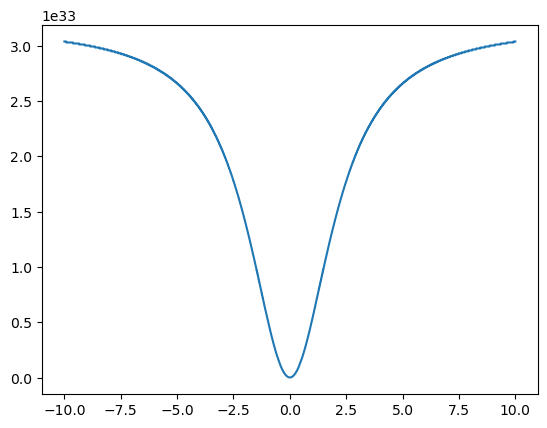

In [ ]:
x = data["freq_1_fit"]
y = data["Syy_1_fit"]
plt.plot(x,y)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)